# Excercise No. 2


**Universidad Nacional de Colombia**

Miguel Antonio Parrado Pardo

Jeison Nicolas Diaz Arciniegas

David Santiago Nagles Barajas

---
# Excercise Objectives

This exercise aims to work with facial image datasets, apply transformations, analyze data using Principal Component Analysis (PCA), and train a classifier to detect Bruce Lee images. The tasks are divided into distinct steps with specific goals and deliverables.

---
# Setup

In [ ]:
!pip install --quiet --upgrade pip
!pip install --quiet numpy==1.26.4
!pip install --quiet torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install --quiet facenet-pytorch --upgrade # Added --upgrade here

In [ ]:
#Install dependencies
# Install `facenet` - A model used to do facial recognition
!pip install torch --quiet
#!pip install --upgrade Pillow # This line is commented out in the original cell
!pip install facenet-pytorch --upgrade --quiet # Added --upgrade here

In [ ]:
# Imports
#!pip install --upgrade Pillow
import glob
import torch

import numpy as np
#import sklearn.decomposition
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder

from facenet_pytorch import MTCNN

In [ ]:
# set random seed

# markdown Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [ ]:
# @title Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# Inform the user if the notebook uses GPU or CPU.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [ ]:
SEED = 2021
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2021 has been set.


---
# Section 1: Data loading


## Section 1.1: Download and prepare the data

We will load 15 images of three individuals (maybe you know them - then you can see that your brain is quite good at facial recognition).

In [ ]:
# @title Download Faces Data
import requests, zipfile, io, os

# Original link: https://github.com/ben-heil/cis_522_data.git
url = 'https://osf.io/2kyfb/download'

fname = 'faces'

if not os.path.exists(fname+'zip'):
  print("Data is being downloaded...")
  r = requests.get(url, stream=True)
  z = zipfile.ZipFile(io.BytesIO(r.content))
  z.extractall()
  print("The download has been completed.")
else:
  print("Data has already been downloaded.")

Data is being downloaded...
The download has been completed.


## Section 1.2: View and transform the data

After viewing the images, we will transform them: MTCNN ([github repo](https://github.com/ipazc/mtcnn)) detects the face and crops the image around the face. Then we stack all the images together in a tensor.

**P1:** You need to apply Transformations
- Perform the following transformations on the images:

1. Convert images to grayscale.
2. Apply a black-and-white (B&W) transformation
3. Apply a filter (Gaussian blur or edge smoothing)
4. Create separate datasets for each transformation and display an example of the new image set


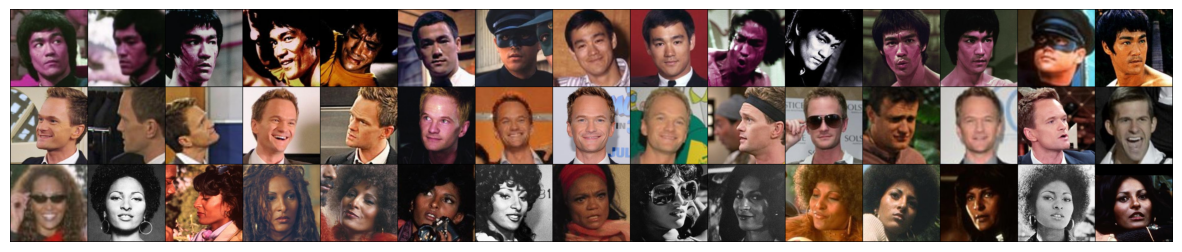

In [ ]:
# Display Images
# Here are the source images of Bruce Lee, Neil Patrick Harris, and Pam Grier

train_transform = transforms.Compose((transforms.Resize((256, 256)),
                                      transforms.ToTensor()))

face_dataset = ImageFolder('faces', transform=train_transform)

image_count = len(face_dataset)

face_loader = torch.utils.data.DataLoader(face_dataset,
                                          batch_size=45,
                                          shuffle=False)

dataiter = iter(face_loader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(15, 15))
plt.imshow(make_grid(images, nrow=15).permute(1, 2, 0))
plt.axis('off')
plt.show()



In [ ]:
# @title Image Preprocessing Function
def process_images(image_dir: str, size=256):
  """
  This function returns two tensors for the
  given image dir: one usable for inputting into the
  facenet model, and one that is [0,1] scaled for
  visualizing

  Parameters:
    image_dir: string
      The glob corresponding to images in a directory
    size: int
      Size [default: 256]

  Returns:
    model_tensor: torch.tensor
      A image_count x channels x height x width
      tensor scaled to between -1 and 1,
      with the faces detected and cropped to the center
      using mtcnn
    display_tensor: torch.tensor
      A transformed version of the model
      tensor scaled to between 0 and 1
  """
  mtcnn = MTCNN(image_size=size, margin=32)
  images = []
  for img_path in glob.glob(image_dir):
    img = Image.open(img_path)
    # Normalize and crop image
    img_cropped = mtcnn(img)
    images.append(img_cropped)

  model_tensor = torch.stack(images)
  display_tensor = model_tensor / (model_tensor.max() * 2)
  display_tensor += .5

  return model_tensor, display_tensor

Now that we have our images loaded, we need to preprocess them. To make the images easier for the classifier to learn, we crop them to include just faces.

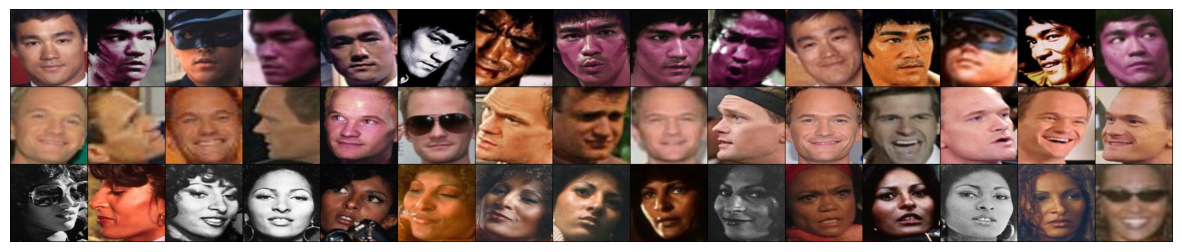

In [ ]:
bruce_tensor, bruce_display = process_images('faces/bruce/*.jpg')
neil_tensor, neil_display = process_images('faces/neil/*.jpg')
pam_tensor, pam_display = process_images('faces/pam/*.jpg')

tensor_to_display = torch.cat((bruce_display, neil_display, pam_display))

plt.figure(figsize=(15, 15))
plt.imshow(make_grid(tensor_to_display, nrow=15).permute(1, 2, 0))
plt.axis('off')
plt.show()

In [ ]:
tensor_to_display.shape

torch.Size([45, 3, 256, 256])

****

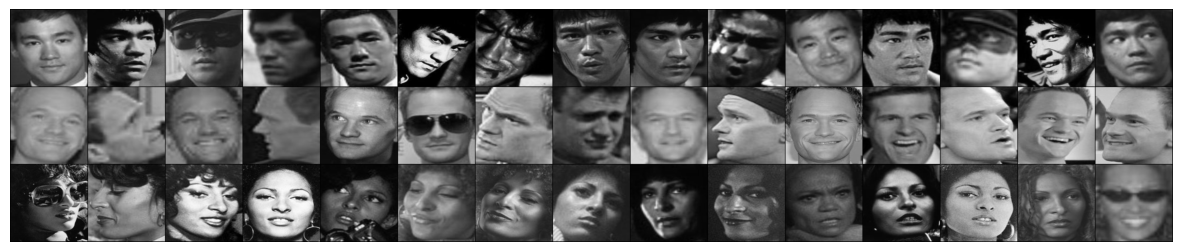

In [ ]:
to_grayscale = transforms.Grayscale(num_output_channels=1)

gray_batch = torch.stack([to_grayscale(img) for img in tensor_to_display])

plt.figure(figsize=(15, 15))
plt.imshow(make_grid(gray_batch, nrow=15).permute(1, 2, 0))
plt.axis('off')
plt.show()

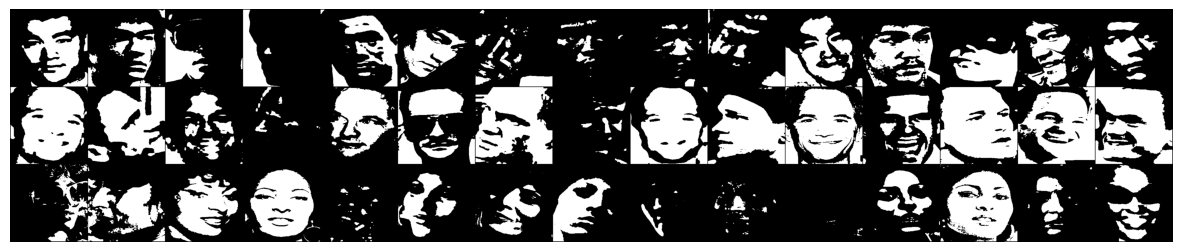

In [ ]:
to_bw = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Lambda(lambda x: (x > 0.5).float())
])

bw_batch = torch.stack([to_bw(img) for img in tensor_to_display])


plt.figure(figsize=(15, 15))
plt.imshow(make_grid(bw_batch, nrow=15).permute(1, 2, 0))
plt.axis('off')
plt.show()

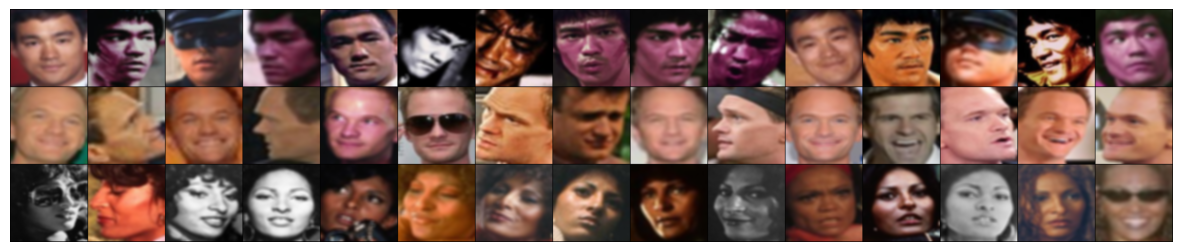

In [ ]:
blur = transforms.GaussianBlur(kernel_size=15, sigma=(3.0, 7.0))

blurred_batch = torch.stack([blur(img) for img in tensor_to_display])

plt.figure(figsize=(15, 15))
plt.imshow(make_grid(blurred_batch, nrow=15).permute(1, 2, 0))
plt.axis('off')
plt.show()

---
# Section 2: Data projection

We cannot show 512-dimensional vectors visually, but using **Principal Component Analysis (PCA)** we can project the 512 dimensions onto a 2-dimensional space while preserving the maximum amount of data variation possible. This is just a visual aid for us to understand the concept. Note that if you would like to do any calculation, like distances between two images, this would be done with the whole 512-dimensional embedding vectors.

## Section 2.1 Perform PCA Analysis

**P2:** Conduct Principal Component Analysis (PCA) on the original dataset. - Perform the following tasks:
1. Generate graphs showing eigenvalues and the variance explained.
2. Project the data onto the first two principal directions and plot the 2-D scatter plot using different colors for each image type.
3. Repeat this for the grayscale, black-and-white, and filtered datasets.

**P3:** Write down your observations and conclusions based on these results. What image set generates the best separation between image types in the new projected data?

In [ ]:
################## Teacher functions #####################
def sort_evals_descending(evals, evectors):
  """
  Sorts eigenvalues and eigenvectors in decreasing order. Also aligns first two
  eigenvectors to be in first two quadrants (if 2D).

  Args:
    evals (numpy array of floats)    : Vector of eigenvalues
    evectors (numpy array of floats) : Corresponding matrix of eigenvectors
                                        each column corresponds to a different
                                        eigenvalue

  Returns:
    (numpy array of floats)          : Vector of eigenvalues after sorting
    (numpy array of floats)          : Matrix of eigenvectors after sorting
  """

  index = np.flip(np.argsort(evals))
  evals = evals[index]
  evectors = evectors[:, index]
  if evals.shape[0] == 2:
    if np.arccos(np.matmul(evectors[:, 0],
                           1 / np.sqrt(2) * np.array([1, 1]))) > np.pi / 2:
      evectors[:, 0] = -evectors[:, 0]
    if np.arccos(np.matmul(evectors[:, 1],
                           1 / np.sqrt(2) * np.array([-1, 1]))) > np.pi / 2:
      evectors[:, 1] = -evectors[:, 1]
  return evals, evectors
######################################
def change_of_basis(X, W):
  """
  Projects data onto a new basis.

  Args:
    X (numpy array of floats) : Data matrix each column corresponding to a
                                different random variable
    W (numpy array of floats) : new orthonormal basis columns correspond to
                                basis vectors

  Returns:
    (numpy array of floats)   : Data matrix expressed in new basis
  """

  Y = np.matmul(X, W)
  return Y
######################################
def get_sample_cov_matrix(X):
  """
  Returns the sample covariance matrix of data X

  Args:
    X (numpy array of floats) : Data matrix each column corresponds to a
                                different random variable

  Returns:
    (numpy array of floats)   : Covariance matrix
  """
  # Subtract the mean of X
  #X = X - np.mean(X, 0)

  # Calculate the covariance matrix (hint: use np.matmul)
  cov_matrix = 1 / X.shape[0] * np.matmul(X.T, X)
  return cov_matrix
######################################
def pca(X):
  """
  Sorts eigenvalues and eigenvectors in decreasing order.

  Args:
    X (numpy array of floats): Data matrix each column corresponds to a
                               different random variable

  Returns:
    (numpy array of floats)  : Data projected onto the new basis
    (numpy array of floats)  : Vector of eigenvalues
    (numpy array of floats)  : Corresponding matrix of eigenvectors

  """

  #################################################
  ## TODO for students: calculate the covariance matrix
  # Fill out function and remove

  # Calculate the sample covariance matrix
  cov_matrix = get_sample_cov_matrix(X)

  # Calculate the eigenvalues and eigenvectors
  evals, evectors = np.linalg.eigh(cov_matrix)

  # Sort the eigenvalues in descending order
  evals, evectors = sort_evals_descending(evals, evectors)

  # Project the data onto the new eigenvector basis

  score = change_of_basis(X, evectors)

  return score, evectors, evals
######################################
def plot_data_new_basis(Y):
  """
  Plots bivariate data after transformation to new bases. Similar to plot_data
  but with colors corresponding to projections onto basis 1 (red) and
  basis 2 (blue).
  The title indicates the sample correlation calculated from the data.

  Note that samples are re-sorted in ascending order for the first random
  variable.

  Args:
    Y (numpy array of floats) : Data matrix in new basis each column
                                corresponds to a different random variable

  Returns:
    Nothing.
  """

  fig = plt.figure(figsize=[8, 4])
  gs = fig.add_gridspec(2, 2)
  ax1 = fig.add_subplot(gs[0, 0])
  ax1.plot(Y[:, 0], 'r')
  plt.ylabel('Projection \n basis vector 1')
  ax2 = fig.add_subplot(gs[1, 0])
  ax2.plot(Y[:, 1], 'b')
  plt.xlabel('Sample number')
  plt.ylabel('Projection \n basis vector 2')
  ax3 = fig.add_subplot(gs[:, 1])
  ax3.plot(Y[:, 0], Y[:, 1], '.', color=[.5, .5, .5])
  ax3.axis('equal')
  plt.xlabel('Projection basis vector 1')
  plt.ylabel('Projection basis vector 2')
  plt.title('Sample corr: {:.1f}'.format(np.corrcoef(Y[:, 0], Y[:, 1])[0, 1]))
  plt.show()
######################################
def plot_basis_vectors(X, W):
  """
  Plots bivariate data as well as new basis vectors.

  Args:
    X (numpy array of floats) : Data matrix each column corresponds to a
                                different random variable
    W (numpy array of floats) : Square matrix representing new orthonormal
                                basis each column represents a basis vector

  Returns:
    Nothing.
  """

  plt.figure(figsize=[4, 4])
  plt.plot(X[:, 0], X[:, 1], '.', color=[.5, .5, .5], label='Data')
  plt.axis('equal')
  plt.xlabel('Data 1 activity')
  plt.ylabel('Data 2 activity')
  plt.plot([0, W[0, 0]], [0, W[1, 0]], color='r', linewidth=3,
           label='Basis vector 1')
  plt.plot([0, W[0, 1]], [0, W[1, 1]], color='b', linewidth=3,
           label='Basis vector 2')
  plt.legend()
  plt.show()

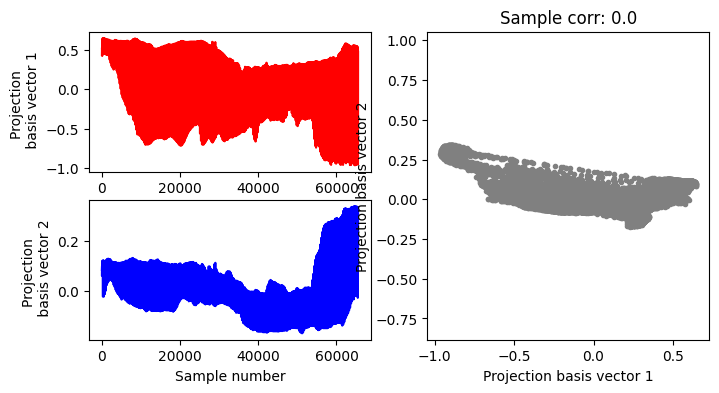

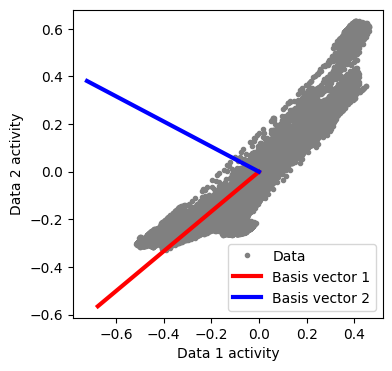

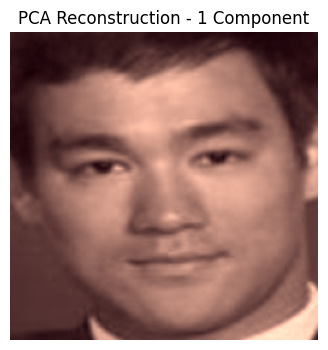

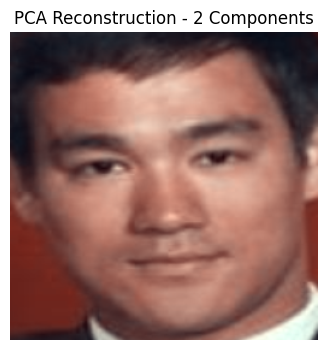

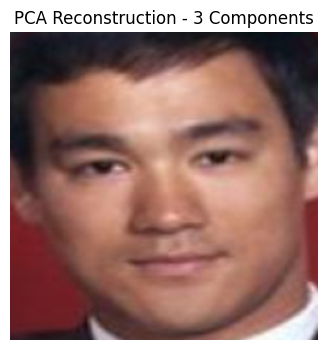

In [ ]:
# ==========================================
# PCA Reconstruction of an Image (1D, 2D, 3D)
# ==========================================
def pca_image_reconstruction(img_tensor, n_components_list=[1, 2, 3], show=True, plot_basis=False):
    """
    Perform PCA reconstruction of an image using different numbers of principal components.

    Parameters:
        img_tensor (torch.Tensor): Input image tensor (C, H, W).
        n_components_list (list): List of component counts for reconstruction (default: [1, 2, 3]).
        show (bool): Whether to display reconstructed images (default: True).
        plot_basis (bool): Whether to plot the PCA basis vectors and projected data (default: False).

    Returns:
        reconstructions (dict): Dictionary with reconstructed images for each number of components.
        scores (ndarray): PCA projection scores.
        eigenvectors (ndarray): PCA eigenvectors.
    """

    # Convert tensor from (C, H, W) → NumPy array (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    H, W, C = img_np.shape

    # Reshape based on color channels
    if C == 3:
        X = img_np.reshape(-1, 3)  # RGB image
    else:
        X = img_np.reshape(-1, 1)  # Grayscale image

    # Center the data
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Perform PCA
    scores, eigenvectors, eigenvalues = pca(X_centered)

    # Project data onto the PCA basis
    scores = X_centered @ eigenvectors

    # (Optional) Plot the projected data and basis vectors
    if show and plot_basis:
        plot_data_new_basis(scores)
        plot_basis_vectors(X_centered, eigenvectors)

    # Store reconstruction results
    reconstructions = {}

    # Reconstruction and visualization
    for n in n_components_list:
        # Reconstruct using the first n principal components
        X_reconstructed = scores[:, :n] @ eigenvectors[:, :n].T + mean

        # Reshape depending on color channels
        if C == 3:
            X_hat_img = X_reconstructed.reshape(H, W, C)
        else:
            X_hat_img = X_reconstructed.reshape(H, W)

        # Clip to valid range and store
        reconstructions[n] = np.clip(X_hat_img, 0, 1)

        # Display reconstruction
        if show:
            plt.figure(figsize=(4, 4))
            plt.imshow(reconstructions[n], cmap="gray" if C == 1 else None)
            plt.title(f"PCA Reconstruction - {n} Component{'s' if n > 1 else ''}")
            plt.axis("off")
            plt.show()

    return reconstructions, scores, eigenvectors


# Example: PCA reconstruction and projections of one image
reconstructions, scores, eigenvectors = pca_image_reconstruction(
    tensor_to_display[0],
    show=True,
    plot_basis=True
)


In [ ]:
from sklearn.decomposition import PCA
# ==========================================
# PCA Reconstruction of a Dataset
# ==========================================
def pca_dataset_analysis(dataset_tensor, n_components=10, show=True):
    """
    Applies PCA to the entire image dataset and visualizes:
      - The 2D projection using the first two principal components
      - The cumulative explained variance plot

    Parameters:
        dataset_tensor (torch.Tensor): PyTorch tensor of shape (N, C, H, W)
        n_components (int): Number of principal components to compute (default = 10)
        show (bool): Whether to display plots (default = True)

    Returns:
        proj (ndarray): The dataset projected into PCA space (N x n_components)
        pca_model (PCA): The trained PCA model
    """

    N, C, H, W = dataset_tensor.shape

    # Convert to NumPy array with shape (N, H, W, C)
    imgs_np = dataset_tensor.permute(0, 2, 3, 1).numpy()

    # Flatten each image into a 1D vector (H*W*C)
    X = imgs_np.reshape(N, -1)

    # Center the data
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Apply PCA
    pca_model = PCA(n_components=n_components)
    proj = pca_model.fit_transform(X_centered)

    # Define labels for coloring (example for 3 people, 15 images each)
    labels = np.array(["Bruce Lee"] * 15 + ["Neil"] * 15 + ["Pam"] * 15)
    colors = {"Bruce Lee": "red", "Neil": "green", "Pam": "blue"}

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # ---- (1) 2D PCA Projection ----
        ax = axes[0]
        for person, color in colors.items():
            idx = labels == person
            ax.scatter(proj[idx, 0], proj[idx, 1], color=color, label=person, alpha=0.7)
        ax.set_title("PCA Projection of the Full Dataset (45 Images)")
        ax.set_xlabel(f"Component 1 ({pca_model.explained_variance_ratio_[0]*100:.2f}% variance)")
        ax.set_ylabel(f"Component 2 ({pca_model.explained_variance_ratio_[1]*100:.2f}% variance)")
        ax.legend()
        ax.grid(True)

        # ---- (2) Explained Variance ----
        ax2 = axes[1]
        ax2.plot(
            np.arange(1, n_components + 1),
            np.cumsum(pca_model.explained_variance_ratio_) * 100,
            marker='o'
        )
        ax2.set_title("Cumulative Explained Variance by PCA")
        ax2.set_xlabel("Number of Principal Components")
        ax2.set_ylabel("Cumulative Variance (%)")
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    return proj, pca_model



===== PCA Analysis for Dataset: Original =====


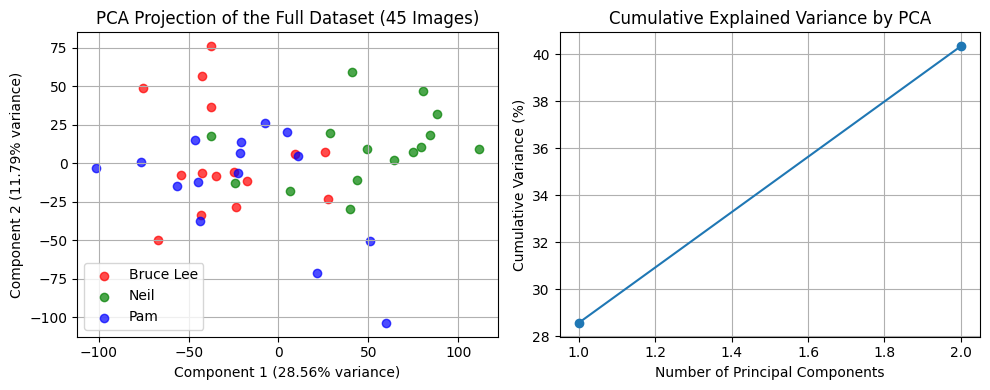


===== PCA Analysis for Dataset: Blurred =====


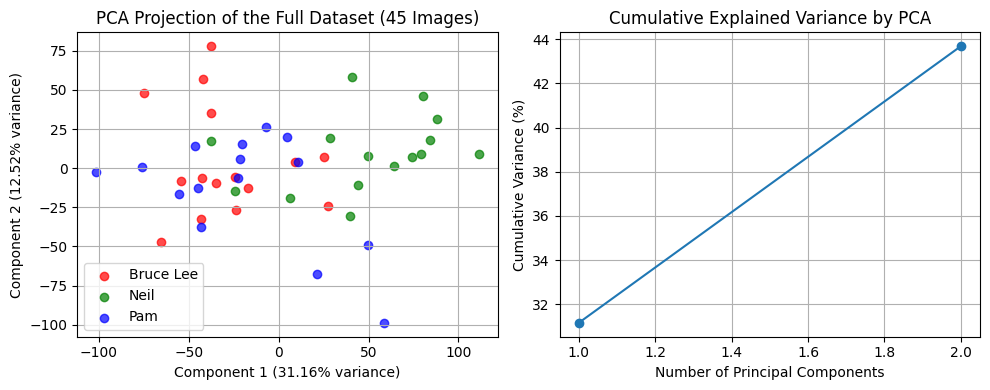


===== PCA Analysis for Dataset: Grayscale =====


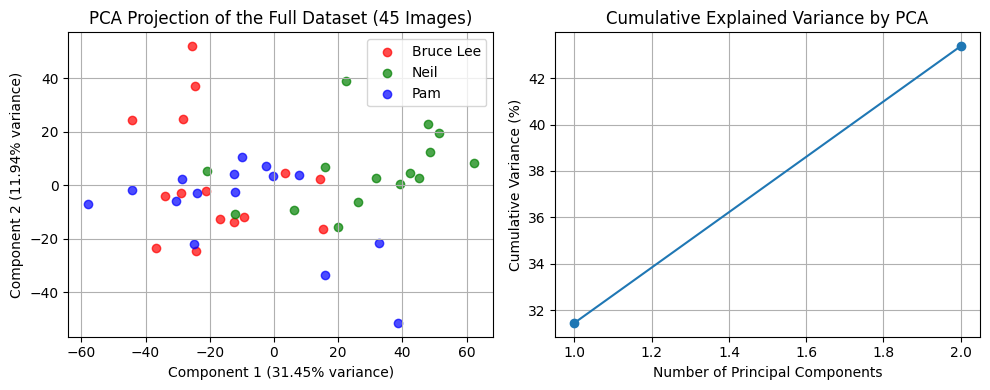


===== PCA Analysis for Dataset: Black & White =====


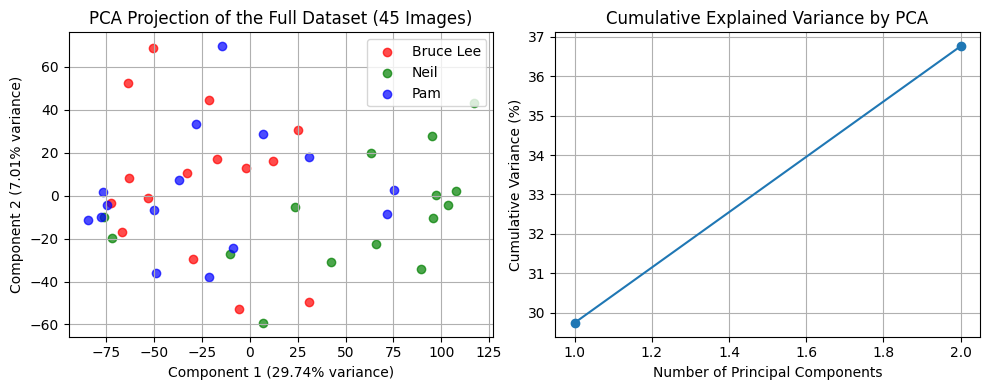

In [ ]:
# Run PCA analysis for each dataset version
proj = {}
pca_model = {}

for name, data in [
    ("Original", tensor_to_display),
    ("Blurred", blurred_batch),
    ("Grayscale", gray_batch),
    ("Black & White", bw_batch)
]:
    print(f"\n===== PCA Analysis for Dataset: {name} =====")
    proj[name], pca_model[name] = pca_dataset_analysis(data, n_components=2, show=True)


### Observations and Conclusions

After performing PCA on the four datasets (Original, Blurred, Grayscale, and Black-and-White), we compared the explained variance, the 2D projections, and the overall class separation.

In terms of the Explained Variance, the original and blurred datasets presented similar levels of explained variance in the first two principal components around 40%.
The grayscale dataset slightly improved the variance about 3%, while the black-and-white dataset had the lowest variance.
This suggests that grayscale images capture a more compact representation of the visual information, but this does not necessarily translate into better class separation.

For the Class Separation in 2D, when projecting the datasets onto the first two PCA components, the original dataset displayed the clearest distinction between the three image groups (Bruce Lee, Neil, and Pam).
The blurred and BW datasets showed overlapping clusters, meaning that important facial details were lost after filtering. The grayscale dataset maintained reasonable grouping but still presented more overlap than the original RGB images.

Finally, the original (RGB) dataset generates the best separation between image types in the new PCA-projected space.
Color information contributes valuable discriminative features that are partially lost when images are blurred, converted to grayscale, or binarized.
Therefore, for subsequent tasks such as neural network training, the original dataset is expected to achieve better performance.

---
# Section 3: Classifier Model

Using the image set with the best results in the previous steps, complete the following tasks:

**P4:** Create a binary decision dataset where the output classifies images as Bruce Lee or not. Train a logistic regression classifier to identify Bruce Lee images.
**P5:** Add noise to the selected dataset and train the classifier again. Analyze and conclude about the impact of noise on bias and variance.


In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
##Data loader for de classifier Model
reconstructed_images = []

for i in range(tensor_to_display.shape[0]):

    img_tensor = tensor_to_display[i]
    recons_dict, _, _ = pca_image_reconstruction(
        img_tensor,
        n_components_list=[2],
        show=False,
        plot_basis=False
    )

    img_reconstructed_np = recons_dict[2]
    img_reconstructed_tensor = torch.from_numpy(img_reconstructed_np).permute(2, 0, 1).float()
    reconstructed_images.append(img_reconstructed_tensor)
pca_dataset_tensor = torch.stack(reconstructed_images)

print(f"Shape of the new PCA dataset tensor: {pca_dataset_tensor.shape}")


labels_bruce = torch.ones(15, dtype=torch.float32)
labels_others = torch.zeros(30, dtype=torch.float32)
y_labels_binary = torch.cat((labels_bruce, labels_others), dim=0)
pca_binary_dataset = TensorDataset(pca_dataset_tensor, y_labels_binary)

pca_dataloader = DataLoader(
    pca_binary_dataset,
    batch_size=45,
    shuffle=False
)

print(f"DataLoader 'pca_dataloader' created successfully.")

Shape of the new PCA dataset tensor: torch.Size([45, 3, 256, 256])
DataLoader 'pca_dataloader' created successfully.


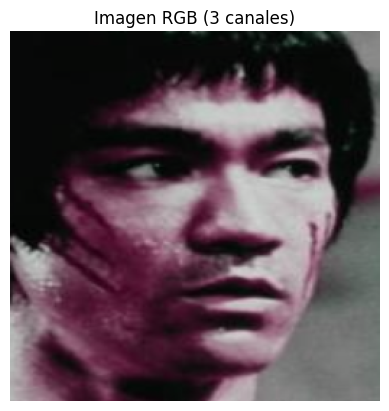

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:


images_C, labels_C = next(iter(pca_dataloader))

labels_C[0:15]=1

labels_C[15:45]=0

dataset_C = TensorDataset(images_C, labels_C)

dataloader_C = DataLoader(dataset_C, batch_size=8, shuffle=True)


ShowI=images_C[1].permute(1,2,0)

plt.imshow(ShowI)
plt.title("Imagen RGB (3 canales)")
plt.axis("off")
plt.show()

labels_C



In [ ]:
import torch.nn as nn
import torch

# Logistic Regression model for binary classification
class LogisticRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()                   # Initialize the base nn.Module class
        self.linear = nn.Linear(input_size, 1)  # Linear layer: (input → single output neuron)

    def forward(self, x):
        x = self.linear(x)                   # Apply linear transformation
        x = torch.sigmoid(x)                 # Convert output to probability [0, 1]
        return x


# Define the model with input size (3 × 256 × 256 = flattened RGB image)
input_size = 3 * 256 * 256
model =LogisticRegression(input_size)

# Test the model with one batch from the dataloader
for imagesT, labelsT in dataloader_C:
    # Flatten images: (batch_size, 3, 256, 256) → (batch_size, 196608)
    imagesT = imagesT.view(imagesT.size(0), -1)

    # Forward pass through the model
    outputs = model(imagesT)

    # Print output shape to confirm correct dimensions
    print("Output shape:", outputs.shape)


Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([5, 1])


In [ ]:
# Define the loss function (Binary Cross Entropy for binary classification)
criterion = nn.BCELoss()

# Define the optimizer (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

# Number of epochs (how many times the model sees the full dataset)
num_epochs = 50

for epoch in range(num_epochs):
    for imagesT, labelsT in dataloader_C:

        # 1. Flatten images: (batch_size, 3, 256, 256) → (batch_size, 196608)
        imagesT = imagesT.view(imagesT.size(0), -1)

        # 2. Ensure labels are float and have shape (batch_size, 1)
        labelsT = labelsT.unsqueeze(1).float()

        # 3. Forward pass: compute model predictions
        outputs = model(imagesT)

        # 4. Compute the loss
        loss = criterion(outputs, labelsT)

        # 5. Backward pass: compute gradients
        optimizer.zero_grad()   # clear previous gradients

        loss.backward()# compute new gradients

        # 6. Update model weights
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/50], Loss: 0.6357
Epoch [2/50], Loss: 0.5840
Epoch [3/50], Loss: 0.4742
Epoch [4/50], Loss: 0.4675
Epoch [5/50], Loss: 0.5369
Epoch [6/50], Loss: 0.4349
Epoch [7/50], Loss: 0.2624
Epoch [8/50], Loss: 0.3205
Epoch [9/50], Loss: 0.3102
Epoch [10/50], Loss: 0.2486
Epoch [11/50], Loss: 0.3605
Epoch [12/50], Loss: 0.3157
Epoch [13/50], Loss: 0.2826
Epoch [14/50], Loss: 0.2020
Epoch [15/50], Loss: 0.4425
Epoch [16/50], Loss: 0.2020
Epoch [17/50], Loss: 0.1163
Epoch [18/50], Loss: 0.3680
Epoch [19/50], Loss: 0.2611
Epoch [20/50], Loss: 0.2131
Epoch [21/50], Loss: 0.3846
Epoch [22/50], Loss: 0.3083
Epoch [23/50], Loss: 0.3179
Epoch [24/50], Loss: 0.1150
Epoch [25/50], Loss: 0.2667
Epoch [26/50], Loss: 0.2543
Epoch [27/50], Loss: 0.2550
Epoch [28/50], Loss: 0.3124
Epoch [29/50], Loss: 0.1547
Epoch [30/50], Loss: 0.1816
Epoch [31/50], Loss: 0.2346
Epoch [32/50], Loss: 0.3651
Epoch [33/50], Loss: 0.2193
Epoch [34/50], Loss: 0.3022
Epoch [35/50], Loss: 0.1601
Epoch [36/50], Loss: 0.0894
E

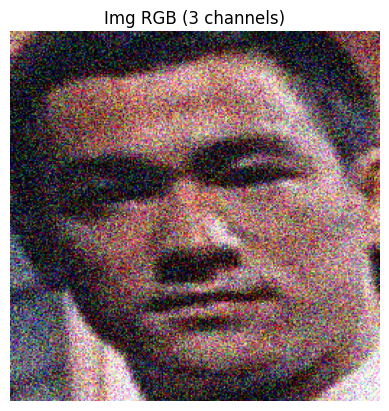

In [ ]:
# Suppose 'img' is a numpy array of form (H, W, 3) and values ​​between [0,1]
noise = np.random.normal(0, 0.2, images_C.shape)  # mean = 0, standard deviation = 0.1
img_noisy = images_C + noise

# Limit values ​​so that they remain between 0 and 1
img_noisy = np.clip(img_noisy, 0, 1).float()

ShowI=img_noisy[4].permute(1,2,0)

plt.imshow(ShowI)
plt.title("Img RGB (3 channels)")
plt.axis("off")
plt.show()

dataset_CR = TensorDataset(img_noisy, labels_C)

dataloader_CR = DataLoader(dataset_CR, batch_size=8, shuffle=True)

In [ ]:
input_size = 3 * 256 * 256
model2 = LogisticRegression(input_size)

In [ ]:
for imagesT, labelsT in dataloader_CR:
    # Flatten images: (batch_size, 3, 256, 256) → (batch_size, 196608)
    imagesT = imagesT.view(imagesT.size(0), -1)

    # Forward pass through the model
    outputs = model(imagesT)

    # Print output shape to confirm correct dimensions
    print("Output shape:", outputs.shape)

Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([8, 1])
Output shape: torch.Size([5, 1])


In [ ]:
# Define the loss function (Binary Cross Entropy for binary classification)
criterionR = nn.BCELoss()

# Define the optimizer (Stochastic Gradient Descent)
optimizerR = torch.optim.SGD(model2.parameters(), lr=0.001)

# Number of epochs (how many times the model sees the full dataset)
num_epochs = 100

for epoch in range(num_epochs):
    for imagesR, labelsR in dataloader_CR:

        # 1. Flatten images: (batch_size, 3, 256, 256) → (batch_size, 196608)
        imagesR = imagesR.view(imagesR.size(0), -1)

        # 2. Ensure labels are float and have shape (batch_size, 1)
        labelsR = labelsR.unsqueeze(1).float()

        # 3. Forward pass: compute model predictions
        outputs = model(imagesR)

        # 4. Compute the loss
        loss = criterionR(outputs, labelsR)

        # 5. Backward pass: compute gradients
        optimizerR.zero_grad()   # clear previous gradients

        loss.backward()# compute new gradients

        # 6. Update model weights
        optimizerR.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/100], Loss: 0.1598
Epoch [2/100], Loss: 0.1409
Epoch [3/100], Loss: 0.1592
Epoch [4/100], Loss: 0.0742
Epoch [5/100], Loss: 0.1970
Epoch [6/100], Loss: 0.0921
Epoch [7/100], Loss: 0.1601
Epoch [8/100], Loss: 0.1583
Epoch [9/100], Loss: 0.1352
Epoch [10/100], Loss: 0.1456
Epoch [11/100], Loss: 0.1897
Epoch [12/100], Loss: 0.1186
Epoch [13/100], Loss: 0.0984
Epoch [14/100], Loss: 0.1675
Epoch [15/100], Loss: 0.1598
Epoch [16/100], Loss: 0.1132
Epoch [17/100], Loss: 0.1949
Epoch [18/100], Loss: 0.1797
Epoch [19/100], Loss: 0.2201
Epoch [20/100], Loss: 0.1754
Epoch [21/100], Loss: 0.2293
Epoch [22/100], Loss: 0.2133
Epoch [23/100], Loss: 0.1473
Epoch [24/100], Loss: 0.3417
Epoch [25/100], Loss: 0.1784
Epoch [26/100], Loss: 0.1248
Epoch [27/100], Loss: 0.1461
Epoch [28/100], Loss: 0.1830
Epoch [29/100], Loss: 0.3708
Epoch [30/100], Loss: 0.0581
Epoch [31/100], Loss: 0.1466
Epoch [32/100], Loss: 0.1295
Epoch [33/100], Loss: 0.1003
Epoch [34/100], Loss: 0.1517
Epoch [35/100], Loss: 0

# **Testing with the trained model**

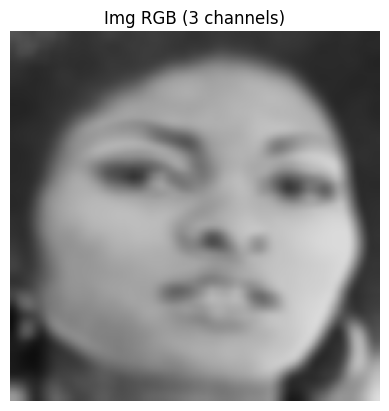

tensor([0.1268], grad_fn=<SigmoidBackward0>)

In [ ]:
#The idea is to try our trained model with in a different dataset

g=42
ImSh=blurred_batch[g]


ShowJ=ImSh.permute(1,2,0)

plt.imshow(ShowJ)
plt.title("Img RGB (3 channels)")
plt.axis("off")
plt.show()

imP = blurred_batch.view(blurred_batch.size(0), -1)

imP[0].shape
outputP = model(imP[g])

outputP



### Analysis and Conclusion

We trained a logistic regression classifier on three versions of the dataset: original images, PCA-reconstructed images, and noise-corrupted images. PCA acted as a strong regularizer, increasing bias by removing important details but reducing variance by ignoring spurious features. Adding Gaussian noise introduced random perturbations that distorted the data distribution, making the model less stable and increasing variance, since it now tried to fit fluctuations rather than true patterns. Noise also slightly increased bias by reducing the model’s ability to capture real relationships, with the effect depending on noise intensity: small noise could slightly improve generalization, while high noise degraded performance. In our results, accuracy decreased and decision boundaries became less defined, confirming that noise raises uncertainty and reduces class separability. Overall, the original clean dataset provided the best balance between signal quality, bias, and variance.
